# Iris Flower Classification

## Objective

The objective of this project is to build machine learning classification models that can identify the species of an iris flower based on its physical measurements.

The three iris species are:
- Setosa
- Versicolor
- Virginica

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Dataset loaded successfully!
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (150, 5)


In [5]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object


In [6]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


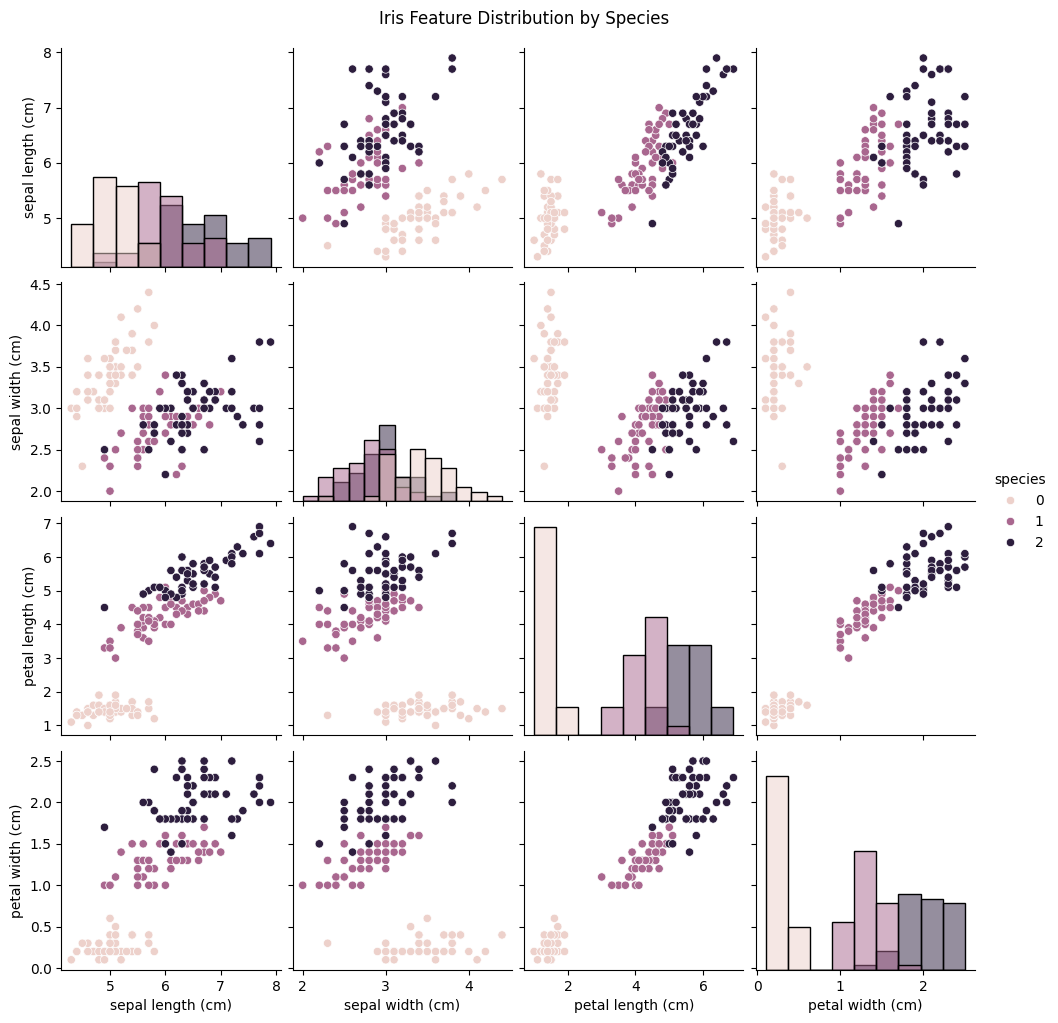

In [8]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle("Iris Feature Distribution by Species", y=1.02)
plt.show()

In [9]:
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


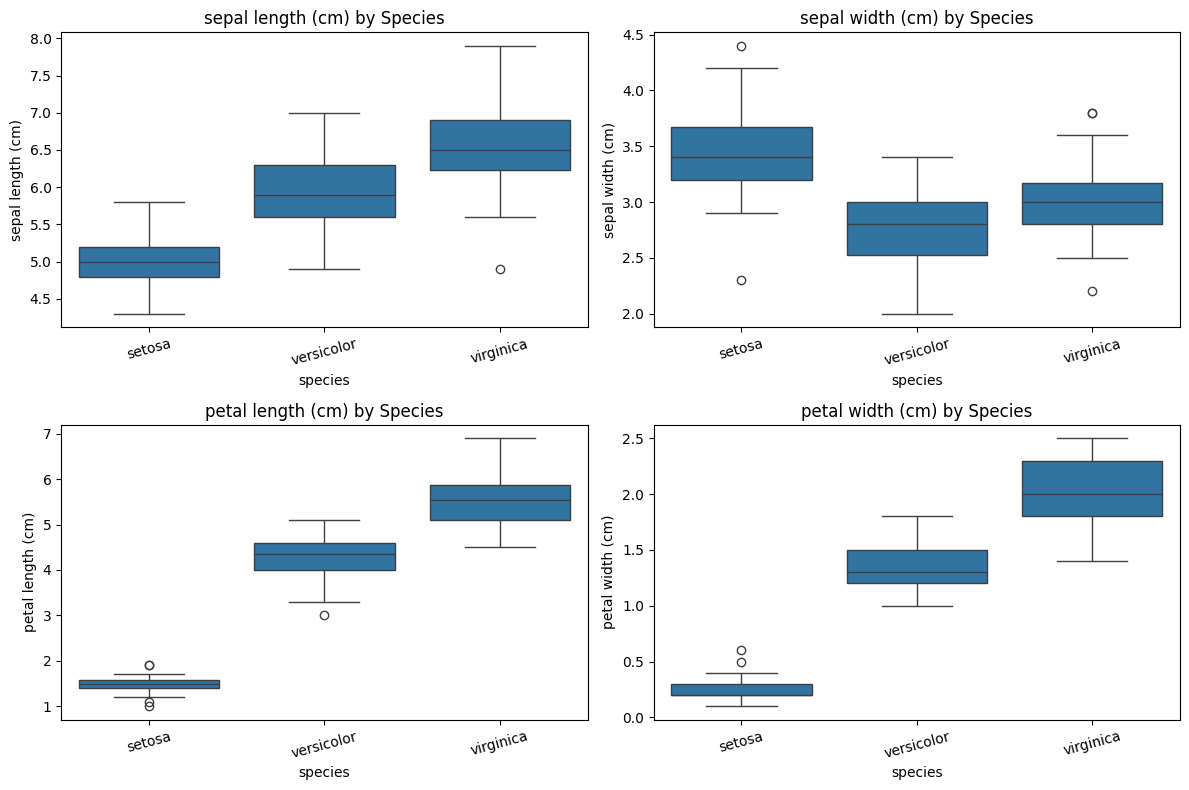

In [10]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=column)
    plt.title(f"{column} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [11]:
X = df[iris.feature_names]
y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred_logistic)

Predictions generated successfully!
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


In [16]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Accuracy Percentage:", logistic_accuracy * 100, "%")

Logistic Regression Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [18]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions generated successfully!")
print(y_pred_knn)

KNN predictions generated successfully!
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


In [19]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy Percentage:", knn_accuracy * 100, "%")

KNN Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


In [20]:
print("Model Comparison")
print("----------------------------")
print(f"Logistic Regression: {logistic_accuracy * 100:.2f}%")
print(f"KNN:                 {knn_accuracy * 100:.2f}%")

Model Comparison
----------------------------
Logistic Regression: 93.33%
KNN:                 93.33%


In [21]:
print("Logistic Regression - Classification Report")
print("---------------------------------------------")

print(classification_report(y_test, y_pred_logistic))

Logistic Regression - Classification Report
---------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [22]:
print("KNN - Classification Report")
print("---------------------------")

print(classification_report(y_test, y_pred_knn))

KNN - Classification Report
---------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



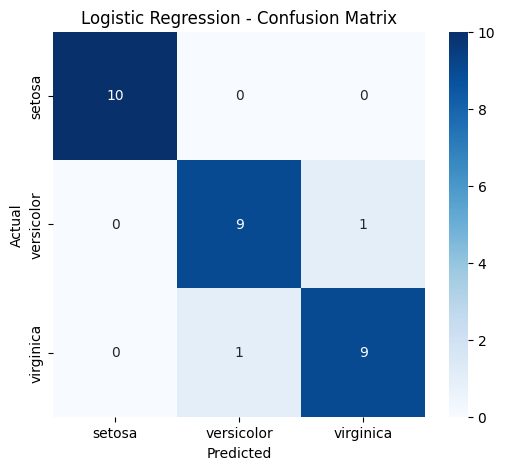

In [23]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

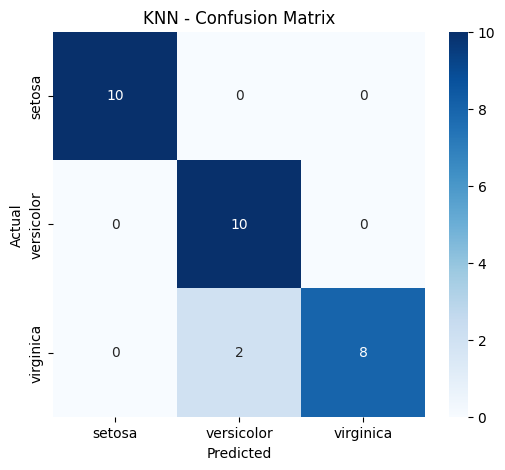

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

In [25]:
if knn_accuracy > logistic_accuracy:
    best_model = "KNN"
    best_accuracy = knn_accuracy
else:
    best_model = "Logistic Regression"
    best_accuracy = logistic_accuracy

print("Best Performing Model:", best_model)
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

Best Performing Model: Logistic Regression
Best Accuracy: 93.33%


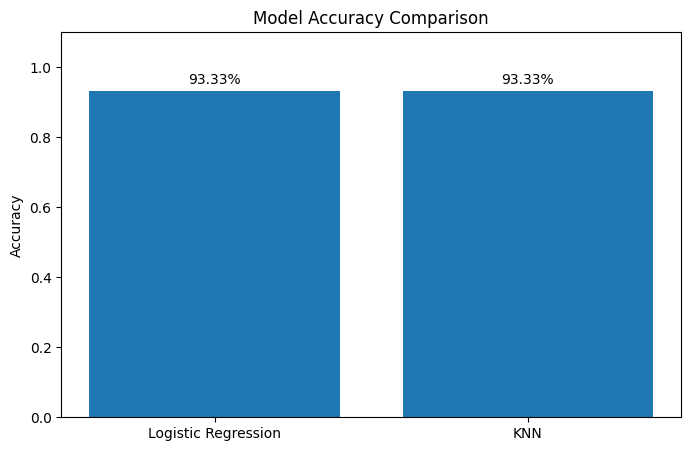

In [26]:
models = ["Logistic Regression", "KNN"]
accuracies = [logistic_accuracy, knn_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy * 100:.2f}%", ha="center")

plt.show()

# Conclusion

In this project, machine learning models were developed to classify iris flowers into Setosa, Versicolor, and Virginica species.

The dataset was explored using descriptive statistics, pairplots, and boxplots. The data was divided into training and testing sets and feature scaling was applied.

Two classification algorithms, Logistic Regression and K-Nearest Neighbors (KNN), were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Based on the evaluation results, the model with the higher accuracy was selected as the best-performing model.

This project demonstrates how machine learning can be used for multi-class classification using flower measurements.